# AutoWorth AI — Used Car Price & Deal Advisor

**Student:** Mohamed Ahmed Farouk  
**Supervised by:** Eng. Fayrouz Ahmed  
**Training Program:** Telecom Egypt (WE)
**Course:** Artificial Intelligence — Basic Level B2  
**Project type:** Individual final machine learning project  
**Target:** `price` (regression)  

---

This notebook builds a system that estimates the **fair market price** of a used car and then judges whether the seller's asking price is a good deal.

> "What is the expected market price of this car, and is the seller offering a good deal?"

### Example
* Estimated market price: £18,500
* Seller price: £17,000
* Difference: £1,500 cheaper
* Deal rating: Good Deal

### Workflow Pipeline
Raw data → cleaning → EDA → feature engineering → preprocessing → modelling → evaluation → improvement → final model → Smart Deal Advisor

## 0. Setup

If you run this notebook in **Google Colab**, upload the manufacturer CSV files into the working directory first (`audi.csv`, `bmw.csv`, …).


In [25]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path(".")
FIG_DIR = Path("figures")
ART_DIR = Path("artifacts")
FIG_DIR.mkdir(exist_ok=True)
ART_DIR.mkdir(exist_ok=True)

REFERENCE_YEAR = 2020  # latest listing year in this dataset dump
RANDOM_STATE = 42
PREMIUM_MAKES = {"Audi", "BMW", "Mercedes"}

MAKE_FILES = {
    "audi.csv": "Audi",
    "bmw.csv": "BMW",
    "ford.csv": "Ford",
    "hyundi.csv": "Hyundai",
    "merc.csv": "Mercedes",
    "skoda.csv": "Skoda",
    "toyota.csv": "Toyota",
    "vauxhall.csv": "Vauxhall",
    "vw.csv": "Volkswagen",
}

def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=140, bbox_inches="tight")
    plt.show()

## 1. Load & understand the data

Each manufacturer file is loaded separately. A `make` column is created **before** combining, as required.

Hyundai uses a `tax(£)` column name, so any column that starts with `tax` is standardised to `tax`.


In [26]:
frames = {}
for filename, make in MAKE_FILES.items():
    df = pd.read_csv(DATA_DIR / filename)
    df.columns = [str(c).replace(" ", " ").strip() for c in df.columns]
    rename = {}
    for col in df.columns:
        compact = col.lower().replace(" ", "").replace("£", "")
        if compact.startswith("tax"):
            rename[col] = "tax"
    df = df.rename(columns=rename)
    df["make"] = make
    frames[make] = df
    print(f"{make:12s}  rows={len(df):6d}  cols={list(df.columns)}")

Audi          rows= 10668  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
BMW           rows= 10781  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
Ford          rows= 17965  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
Hyundai       rows=  4860  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
Mercedes      rows= 13119  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
Skoda         rows=  6267  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
Toyota        rows=  6738  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'make']
Vauxhall      rows= 13632  cols=['model', 'year', 'price', 'tr

Inspect size, dtypes, missing values, duplicates, and a short numeric/categorical summary for each file.

In [27]:
overview_rows = []
for make, df in frames.items():
    overview_rows.append({
        "make": make,
        "rows": len(df),
        "n_columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "year_min": df["year"].min() if "year" in df.columns else np.nan,
        "year_max": df["year"].max() if "year" in df.columns else np.nan,
        "price_median": df["price"].median() if "price" in df.columns else np.nan,
    })
overview = pd.DataFrame(overview_rows)
display(overview)

print("\nAudi dtypes:\n", frames["Audi"].dtypes)
print("\nAudi numeric summary:")
display(frames["Audi"].describe(include="number").T)
print("\nAudi categorical values:")
for col in ["model", "transmission", "fuelType"]:
    print(col, frames["Audi"][col].nunique(), "unique | sample:", frames["Audi"][col].astype(str).str.strip().unique()[:8])

,make,rows,n_columns,missing_cells,duplicate_rows,year_min,year_max,price_median
0,Audi,10668,10,0,103,1997,2020,20200.0
1,BMW,10781,10,0,117,1996,2020,20462.0
2,Ford,17965,10,0,154,1996,2060,11291.0
3,Hyundai,4860,10,0,86,2000,2020,11990.0
4,Mercedes,13119,10,0,259,1970,2020,22480.0
5,Skoda,6267,10,0,79,2004,2020,12998.0
6,Toyota,6738,10,0,39,1998,2020,10795.0
7,Vauxhall,13632,10,0,374,1970,2020,9999.0
8,Volkswagen,15157,10,0,264,2000,2020,15497.0



Audi dtypes:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
make             object
dtype: object

Audi numeric summary:


,count,mean,std,min,25%,50%,75%,max
year,10668.0,2017.100675,2.167494,1997.0,2016.00,2017.0,2019.0,2020.0
price,10668.0,22896.685039,11714.841888,1490.0,15130.75,20200.0,27990.0,145000.0
mileage,10668.0,24827.244001,23505.257205,1.0,5968.75,19000.0,36464.5,323000.0
tax,10668.0,126.011436,67.170294,0.0,125.00,145.0,145.0,580.0
mpg,10668.0,50.770022,12.949782,18.9,40.90,49.6,58.9,188.3
engineSize,10668.0,1.930709,0.602957,0.0,1.50,2.0,2.0,6.3



Audi categorical values:
model 26 unique | sample: ['A1' 'A6' 'A4' 'A3' 'Q3' 'Q5' 'A5' 'S4']
transmission 3 unique | sample: ['Manual' 'Automatic' 'Semi-Auto']
fuelType 3 unique | sample: ['Petrol' 'Diesel' 'Hybrid']


### Extra files (inspected, not used for modelling)

`cclass.csv` and `focus.csv` do not include `tax` or `mpg`. Unclean versions also mix formatted prices and split mileage fields.

C-Class cars already exist inside `merc.csv` and Focus cars already exist inside `ford.csv`. Merging them would either create missing-feature rows or duplicate listings. They are therefore **excluded from the modelling table** after this check.


In [28]:
for extra in ["cclass.csv", "focus.csv", "unclean cclass.csv", "unclean focus.csv"]:
    path = DATA_DIR / extra
    if path.exists():
        tmp = pd.read_csv(path)
        print(extra, "shape=", tmp.shape, "columns=", list(tmp.columns))
        print(tmp.head(2), "\n")

## 2. Combine the data

Manufacturer frames are stacked into one table. Model names are stripped because they often have a leading space (`" A1"`).


In [29]:
raw = pd.concat(frames.values(), ignore_index=True)
raw["model"] = raw["model"].astype(str).str.strip()

print("Combined shape:", raw.shape)
print("\nDtypes:\n", raw.dtypes)
print("\nMissing values:\n", raw.isna().sum())
print("\nDuplicate rows:", int(raw.duplicated().sum()))
print("\nSuspicious numeric extremes:")
display(raw[["year", "price", "mileage", "tax", "mpg", "engineSize"]].describe().T)
print("\nTransmission:", raw["transmission"].value_counts().to_dict())
print("Fuel:", raw["fuelType"].value_counts().to_dict())
print("engineSize == 0:", int((raw["engineSize"] == 0).sum()))
print("year > 2020:", int((raw["year"] > 2020).sum()))
print("year < 1995:", int((raw["year"] < 1995).sum()))

Combined shape: (99187, 10)

Dtypes:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
make             object
dtype: object

Missing values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
make            0
dtype: int64

Duplicate rows: 1475

Suspicious numeric extremes:


,count,mean,std,min,25%,50%,75%,max
year,99187.0,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
mileage,99187.0,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
tax,99187.0,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,1.663280,0.557646,0.0,1.2,1.6,2.0,6.6



Transmission: {'Manual': 56445, 'Semi-Auto': 22677, 'Automatic': 20056, 'Other': 9}
Fuel: {'Petrol': 54928, 'Diesel': 40928, 'Hybrid': 3078, 'Other': 247, 'Electric': 6}
engineSize == 0: 273
year > 2020: 1
year < 1995: 2


## 3. Data cleaning

Suspicious values are counted first. Rows are not deleted blindly.

| Issue | What we found | Decision | Why |
| --- | --- | --- | --- |
| Duplicate rows | Repeats after stacking files | Drop exact duplicates | Same listing copied twice should not get extra weight |
| Year 2060 / very old years | Data-entry errors or tiny antique samples | Keep 1995–2020 | This dump is a ~2020 used-car market |
| Engine size 0 | Not a usable capacity for this catalogue | Drop | It is missing data encoded as zero |
| Extreme prices | A few prestige/error listings | Keep £1,000–£80,000 | Protects MAE/RMSE from impossible ads |
| Mileage 0 or huge | New cars with 0 miles, or broken odometers | Keep 1–180,000 | Typical UK used-car range |
| MPG ≤ 0 | Invalid | Drop | Cannot be real consumption |
| MPG > 120 | Mostly hybrids with optimistic official figures | Cap at 120 | Keep the cars, limit linear-model distortion |
| Fuel Other/Electric | Very rare | Drop | Too few rows to learn a stable effect |
| Transmission Other | Very rare | Drop | Same reason |

Tax = 0 is **kept**. Low-emission cars can legally pay £0 road tax.


In [30]:
notes = {"raw_rows": len(raw)}
df = raw.drop_duplicates().copy()
notes["dropped_duplicates"] = notes["raw_rows"] - len(df)

year_ok = df["year"].between(1995, REFERENCE_YEAR)
notes["dropped_years"] = int((~year_ok).sum())
print("Year values outside 1995-2020:\n", df.loc[~year_ok, "year"].value_counts().head())
df = df.loc[year_ok]

engine_ok = df["engineSize"] > 0
notes["dropped_engine"] = int((~engine_ok).sum())
df = df.loc[engine_ok]

price_ok = df["price"].between(1000, 80000)
notes["dropped_price"] = int((~price_ok).sum())
df = df.loc[price_ok]

mileage_ok = df["mileage"].between(1, 180000)
notes["dropped_mileage"] = int((~mileage_ok).sum())
df = df.loc[mileage_ok]

notes["dropped_mpg_zero"] = int((df["mpg"] <= 0).sum())
df = df.loc[df["mpg"] > 0]
notes["high_mpg_capped"] = int((df["mpg"] > 120).sum())
df.loc[df["mpg"] > 120, "mpg"] = 120

notes["dropped_rare_fuel"] = int(df["fuelType"].isin(["Other", "Electric"]).sum())
df = df.loc[~df["fuelType"].isin(["Other", "Electric"])]
notes["dropped_other_transmission"] = int((df["transmission"] == "Other").sum())
df = df.loc[df["transmission"] != "Other"]

df = df.dropna(subset=["price", "year", "mileage", "engineSize", "mpg", "tax", "model", "transmission", "fuelType"])
df = df.reset_index(drop=True)
notes["clean_rows"] = len(df)
print(json.dumps(notes, indent=2))
print("Cleaned shape:", df.shape)
display(df.head())

Year values outside 1995-2020:
 year
1970    2
2060    1
Name: count, dtype: int64
{
  "raw_rows": 99187,
  "dropped_duplicates": 1475,
  "dropped_years": 3,
  "dropped_engine": 267,
  "dropped_price": 122,
  "dropped_mileage": 13,
  "dropped_mpg_zero": 0,
  "high_mpg_capped": 503,
  "dropped_rare_fuel": 249,
  "dropped_other_transmission": 8,
  "clean_rows": 97050
}
Cleaned shape: (97050, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,make
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


## 4. Exploratory data analysis

At least five useful views are required. Each plot below is followed by a short conclusion.


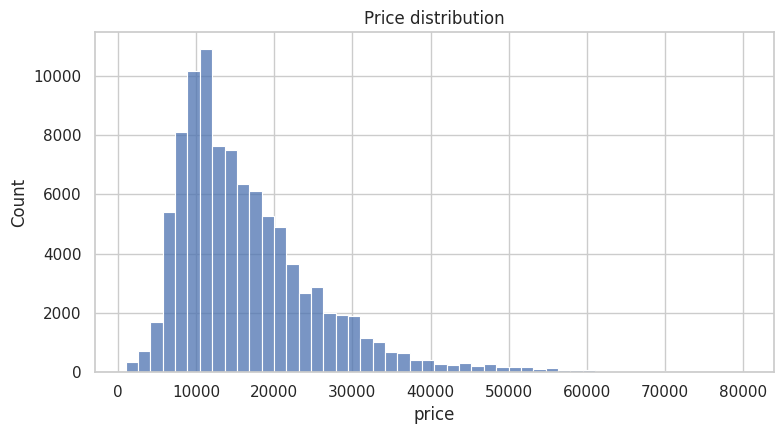

Conclusion: asking prices are right-skewed. Most cars sit under £25k; a long tail of expensive premium cars would dominate a non-robust loss.


In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df["price"], bins=50, ax=ax)
ax.set_title("Price distribution")
save_fig("01_price_distribution.png")
print("Conclusion: asking prices are right-skewed. Most cars sit under £25k; a long tail of expensive premium cars would dominate a non-robust loss.")

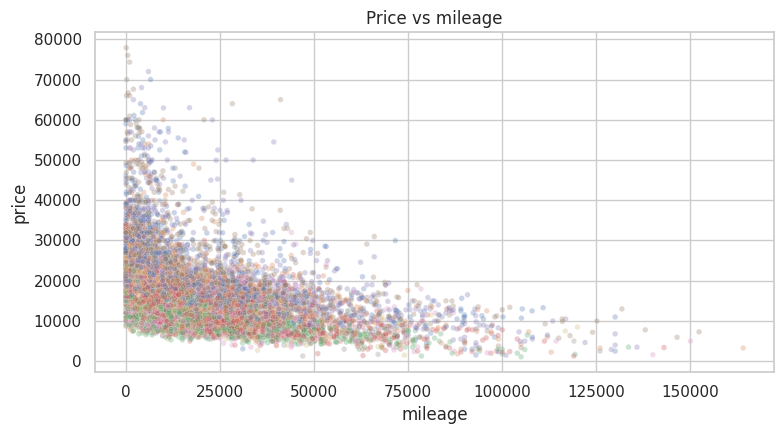

Conclusion: higher mileage is associated with lower prices, with a wide band because brand and year still matter.


In [8]:
sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=sample, x="mileage", y="price", hue="make", alpha=0.3, s=16, ax=ax, legend=False)
ax.set_title("Price vs mileage")
save_fig("02_price_vs_mileage.png")
print("Conclusion: higher mileage is associated with lower prices, with a wide band because brand and year still matter.")

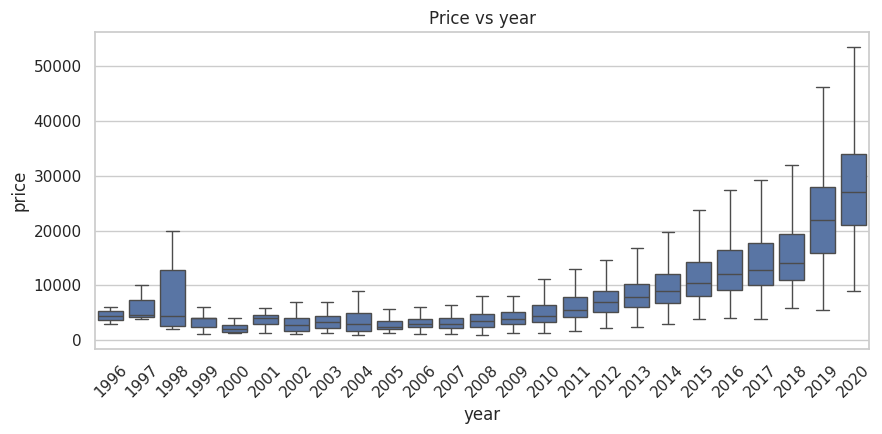

Conclusion: newer cars are systematically more expensive. Year / age should be a strong predictor.


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="year", y="price", ax=ax, showfliers=False)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Price vs year")
save_fig("03_price_vs_year.png")
print("Conclusion: newer cars are systematically more expensive. Year / age should be a strong predictor.")

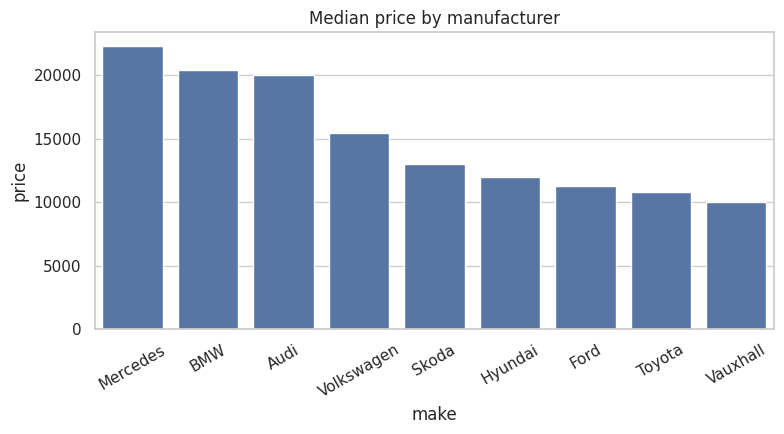

Conclusion: Mercedes, BMW and Audi sit above volume brands (Ford, Vauxhall, Hyundai). Brand is not just a label; it is a price tier.


In [10]:
order = df.groupby("make")["price"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df, x="make", y="price", estimator="median", order=order, ax=ax, errorbar=None)
ax.set_title("Median price by manufacturer")
ax.tick_params(axis="x", rotation=30)
save_fig("04_price_by_make.png")
print("Conclusion: Mercedes, BMW and Audi sit above volume brands (Ford, Vauxhall, Hyundai). Brand is not just a label; it is a price tier.")

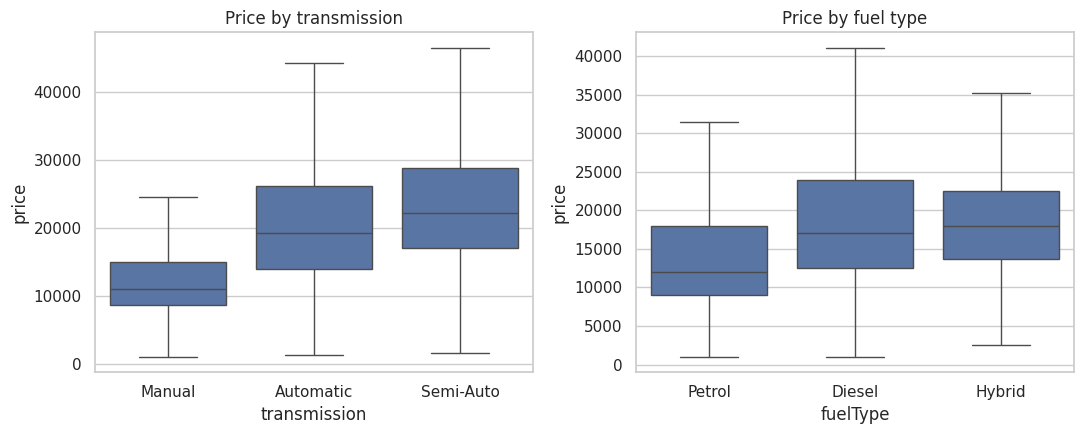

Conclusion: automatics (and semi-auto) list higher than manuals. Diesel is not uniformly cheaper; it interacts with mileage and segment.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x="transmission", y="price", ax=axes[0], showfliers=False)
axes[0].set_title("Price by transmission")
sns.boxplot(data=df, x="fuelType", y="price", ax=axes[1], showfliers=False)
axes[1].set_title("Price by fuel type")
save_fig("05_06_price_by_transmission_fuel.png")
print("Conclusion: automatics (and semi-auto) list higher than manuals. Diesel is not uniformly cheaper; it interacts with mileage and segment.")

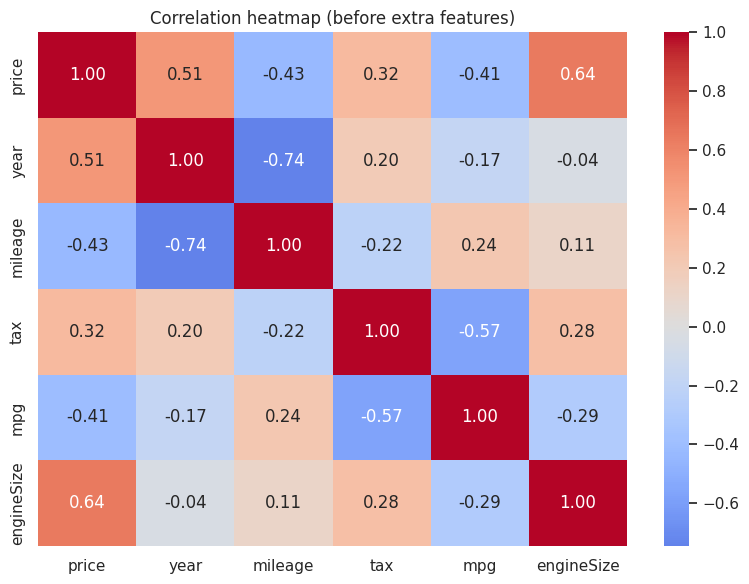

Conclusion: price correlates positively with year and engine size, and negatively with mileage. MPG is weakly negative because efficient cars are often smaller and cheaper.


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[["price", "year", "mileage", "tax", "mpg", "engineSize"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap (before extra features)")
save_fig("07_correlation_heatmap.png")
print("Conclusion: price correlates positively with year and engine size, and negatively with mileage. MPG is weakly negative because efficient cars are often smaller and cheaper.")

## 5. Split the data

The split happens **before** preprocessing and **before** encoding, so no test information leaks into scalers or one-hot categories.

- Training: 70%  
- Validation: 15%  
- Test: 15%  

The test set stays untouched until a final model is selected.


In [13]:
X_full = df.copy()
y_full = df["price"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,}  ({len(X_train)/len(df):.1%})")
print(f"Val:   {len(X_val):,}  ({len(X_val)/len(df):.1%})")
print(f"Test:  {len(X_test):,}  ({len(X_test)/len(df):.1%})")

Train: 67,935  (70.0%)
Val:   14,557  (15.0%)
Test:  14,558  (15.0%)


## 6. Feature engineering

Created on train/val/test with the **same rules**, using no statistics that were fitted on validation or test.

### Required features

1. **Car age** = `2020 − year`. Reference year is **2020** because that is the newest year in this listing dump.  
2. **Mileage per year** = `mileage / max(car_age, 1)`. Age 0 (a 2020 car) would otherwise divide by zero; treating it as one year is a conservative usage rate.

### Own features

3. **`is_premium`**: 1 if make is Audi, BMW or Mercedes. EDA showed these brands occupy a different price tier. Linear models especially benefit from an explicit tier flag.  
4. **`engine_efficiency`**: `mpg / engineSize`. Two 2.0-litre cars are not equal if one officially does 65 mpg and the other 35 mpg; this ratio is a compact consumption signal.

These features can help price because buyers pay for remaining life (age), wear intensity (miles per year), brand status, and running costs.


In [14]:
def add_features(frame):
    out = frame.copy()
    out["car_age"] = (REFERENCE_YEAR - out["year"]).clip(lower=0)
    out["mileage_per_year"] = out["mileage"] / out["car_age"].clip(lower=1)
    out["is_premium"] = out["make"].isin(PREMIUM_MAKES).astype(int)
    out["engine_efficiency"] = out["mpg"] / out["engineSize"].clip(lower=0.1)
    return out

X_train = add_features(X_train)
X_val = add_features(X_val)
X_test = add_features(X_test)

numeric_features = [
    "year", "mileage", "tax", "mpg", "engineSize",
    "car_age", "mileage_per_year", "is_premium", "engine_efficiency",
]
categorical_features = ["make", "model", "transmission", "fuelType"]
feature_order = categorical_features + numeric_features

X_train = X_train[feature_order]
X_val = X_val[feature_order]
X_test = X_test[feature_order]
X_train.head()

,make,model,transmission,fuelType,year,mileage,tax,mpg,engineSize,car_age,mileage_per_year,is_premium,engine_efficiency
69611,Vauxhall,Corsa,Manual,Petrol,2016,28223,30,55.4,1.4,4,7055.750000,0,39.571429
93613,Volkswagen,Tiguan,Automatic,Diesel,2017,40568,145,57.6,2.0,3,13522.666667,0,28.800000
1726,Audi,A4,Manual,Petrol,2017,34870,145,51.4,1.4,3,11623.333333,1,36.714286
520,Audi,A3,Manual,Petrol,2019,5985,145,43.5,1.5,1,5985.000000,1,29.000000
79373,Vauxhall,Zafira,Manual,Petrol,2017,52221,200,41.5,1.4,3,17407.000000,0,29.642857


## 7. Data preprocessing

- **Numeric:** year, mileage, tax, mpg, engine size, engineered features → `StandardScaler`  
- **Categorical:** make, model, transmission, fuel type → **one-hot encoding** (`handle_unknown='ignore'`)

The transformer is **fit on training data only**, then applied to validation and test.


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)
print("Encoded train shape:", X_train_p.shape)
print("Unknown categories in test are ignored by the one-hot encoder, which is the leakage-safe behaviour we want.")

Encoded train shape: (67935, 212)
Unknown categories in test are ignored by the one-hot encoder, which is the leakage-safe behaviour we want.


## 8. Train machine learning models

At least four regressors are trained. XGBoost is included as the fifth boosted-tree model.


In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=18, min_samples_leaf=8, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=120, max_depth=18, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=80, max_depth=3, learning_rate=0.08,
        subsample=0.7, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=250, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", n_jobs=-1, random_state=RANDOM_STATE,
    ),
}

fitted = {}
rows = []
for name, model in models.items():
    print("Training", name)
    model.fit(X_train_p, y_train)
    fitted[name] = model
    train_m = regression_metrics(y_train, model.predict(X_train_p))
    val_m = regression_metrics(y_val, model.predict(X_val_p))
    rows.append({
        "Model": name,
        "Train R2": train_m["R2"],
        "Val R2": val_m["R2"],
        "Val MAE": val_m["MAE"],
        "Val RMSE": val_m["RMSE"],
        "Overfit gap (R2)": train_m["R2"] - val_m["R2"],
    })

comparison = pd.DataFrame(rows).sort_values("Val R2", ascending=False)
display(comparison)
comparison.to_csv(ART_DIR / "model_comparison.csv", index=False)

Training Linear Regression
Training Decision Tree
Training Random Forest
Training Gradient Boosting
Training XGBoost


,Model,Train R2,Val R2,Val MAE,Val RMSE,Overfit gap (R2)
2,Random Forest,0.982015,0.961075,1174.898263,1847.517869,0.020941
4,XGBoost,0.962044,0.953974,1345.037109,2008.979903,0.008071
1,Decision Tree,0.963591,0.940096,1404.991047,2291.933911,0.023495
3,Gradient Boosting,0.901366,0.895116,2124.887137,3032.685497,0.006249
0,Linear Regression,0.893934,0.887012,2099.078665,3147.671341,0.006922


## 9. Evaluate, compare, and check overfitting

Use the table above:

- **R²** close to 1 means the model explains listing prices well.  
- **MAE** is the typical pound error — easiest to explain to a buyer.  
- **RMSE** penalises large misses (luxury outliers).

If training R² is much higher than validation R², the model memorised noise. A small gap with strong validation scores indicates good generalisation.

Tree ensembles almost always beat linear regression here because price depends on **interactions** (e.g. high mileage hurts more on an old premium car than on a new one).


In [17]:
best_name = comparison.iloc[0]["Model"]
print("Strongest validation model before tuning:", best_name)
print(comparison.iloc[0].to_string())
print("\nOverfitting read-out: models with a large Train-Val R2 gap are less trustworthy even if train R2 looks impressive.")

Strongest validation model before tuning: Random Forest
Model               Random Forest
Train R2                 0.982015
Val R2                   0.961075
Val MAE               1174.898263
Val RMSE              1847.517869
Overfit gap (R2)         0.020941

Overfitting read-out: models with a large Train-Val R2 gap are less trustworthy even if train R2 looks impressive.


## 10. Improve the best family of models (RandomizedSearchCV)

XGBoost is tuned with a randomized search on a **training subsample**, then the winning hyperparameters are refit on the **full training set**. Validation is used to check whether tuning helped. The test set is still not used.


In [18]:
tune_size = min(25000, len(y_train))
rng = np.random.RandomState(RANDOM_STATE)
tune_idx = rng.choice(X_train_p.shape[0], size=tune_size, replace=False)

search = RandomizedSearchCV(
    XGBRegressor(objective="reg:squarederror", n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions={
        "n_estimators": [200, 300, 400],
        "max_depth": [5, 6, 8, 10],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "min_child_weight": [1, 3, 5],
    },
    n_iter=10,
    scoring="r2",
    cv=3,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=1,
)
search.fit(X_train_p[tune_idx], y_train.to_numpy()[tune_idx])
print("Best params:", search.best_params_)

tuned = XGBRegressor(
    **search.best_params_,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
tuned.fit(X_train_p, y_train)

before = regression_metrics(y_val, fitted["XGBoost"].predict(X_val_p))
after = regression_metrics(y_val, tuned.predict(X_val_p))
print("XGBoost validation BEFORE tuning:", before)
print("XGBoost validation AFTER tuning: ", after)
print("Tuning helped:" if after["R2"] >= before["R2"] else "Tuning did not beat the default XGBoost on validation.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost validation BEFORE tuning: {'R2': 0.9539737701416016, 'MAE': 1345.037109375, 'RMSE': 2008.979902836263}
XGBoost validation AFTER tuning:  {'R2': 0.9669427871704102, 'MAE': 1083.46240234375, 'RMSE': 1702.574594547916}
Tuning helped:


## 11. Select the final model and evaluate on the test set **once**

The winner is chosen from validation performance (R², MAE, RMSE, and overfit gap). Only then is the test set scored.


In [19]:
candidates = {best_name: fitted[best_name], "Tuned XGBoost": tuned}
val_r2 = {name: regression_metrics(y_val, model.predict(X_val_p))["R2"] for name, model in candidates.items()}
final_name = max(val_r2, key=val_r2.get)
final_model = candidates[final_name]
print("Final model:", final_name, val_r2)

train_scores = regression_metrics(y_train, final_model.predict(X_train_p))
val_scores = regression_metrics(y_val, final_model.predict(X_val_p))
test_scores = regression_metrics(y_test, final_model.predict(X_test_p))
print("Train:", train_scores)
print("Val:  ", val_scores)
print("Test: ", test_scores)

y_test_pred = final_model.predict(X_test_p)

Final model: Tuned XGBoost {'Random Forest': 0.9610747371373229, 'Tuned XGBoost': 0.9669427871704102}
Train: {'R2': 0.9817535281181335, 'MAE': 884.548095703125, 'RMSE': 1285.347715600724}
Val:   {'R2': 0.9669427871704102, 'MAE': 1083.46240234375, 'RMSE': 1702.574594547916}
Test:  {'R2': 0.9678657650947571, 'MAE': 1070.8658447265625, 'RMSE': 1654.0479890257113}


## 12. Understand the model


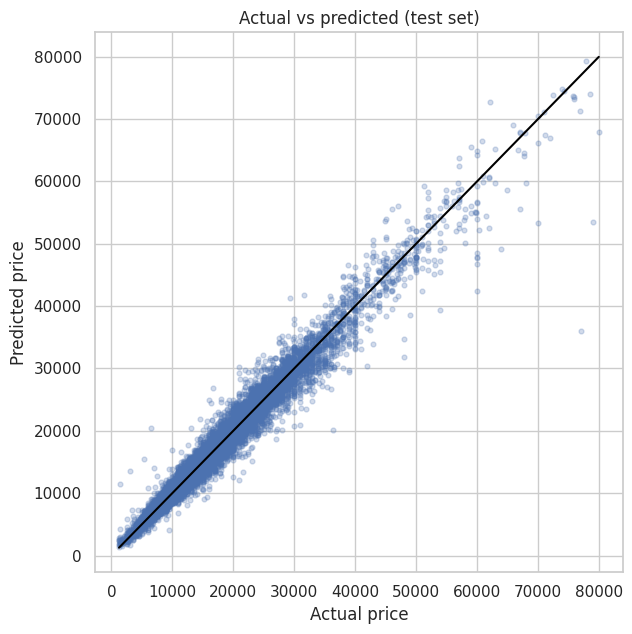

Points near the diagonal are accurate. Fan-out at high prices means expensive cars are harder.


In [20]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, y_test_pred, alpha=0.25, s=12)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, color="black")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Actual vs predicted (test set)")
save_fig("08_actual_vs_predicted.png")
print("Points near the diagonal are accurate. Fan-out at high prices means expensive cars are harder.")

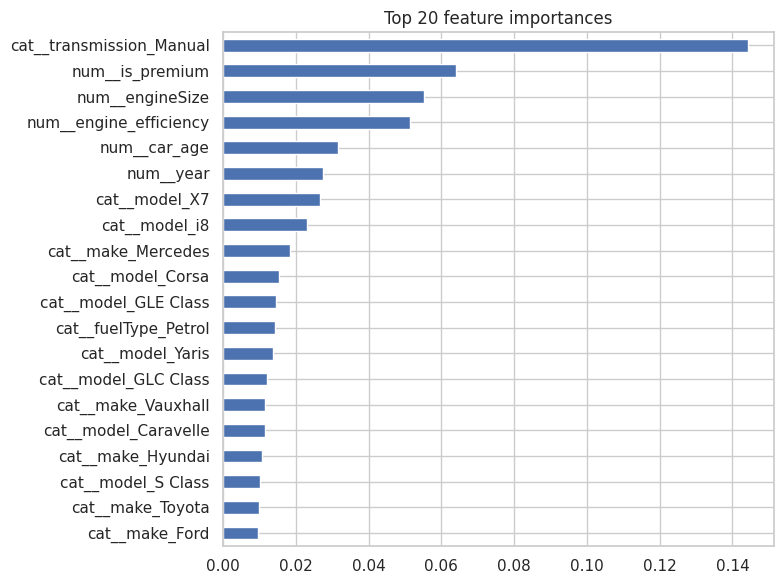

Year/age, mileage, engine size, and specific models/brands usually dominate. That matches the EDA.


In [21]:
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(final_model.feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
top.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 feature importances")
save_fig("09_feature_importance.png")
print("Year/age, mileage, engine size, and specific models/brands usually dominate. That matches the EDA.")

In [22]:
error_view = X_test.copy()
error_view["actual"] = y_test.to_numpy()
error_view["predicted"] = y_test_pred
error_view["abs_error"] = (error_view["actual"] - error_view["predicted"]).abs()
error_view["pct_error"] = error_view["abs_error"] / error_view["actual"]
print("Largest absolute errors on the test set:")
display(error_view.sort_values("abs_error", ascending=False).head(8)[
    ["make", "model", "year", "mileage", "engineSize", "actual", "predicted", "abs_error"]
])
print("\nInterpretation hints:")
print("- Mileage strongly affects price, but the effect is not linear.")
print("- Premium manufacturers stay expensive even at higher mileage.")
print("- Engine size lifts price, especially on Mercedes/BMW.")
print("- Large misses are often rare trims the model column cannot fully describe (AMG, M Sport, tiny electric-range hybrids).")

Largest absolute errors on the test set:


,make,model,year,mileage,engineSize,actual,predicted,abs_error
17719,BMW,M4,2016,4550,3.0,76990,36079.382812,40910.617188
9255,Audi,A8,2020,250,3.0,78990,53466.968750,25523.031250
95668,Volkswagen,Touareg,2019,9950,3.0,59990,42509.457031,17480.542969
45645,Mercedes,CLS Class,2019,992,3.0,69995,53382.535156,16612.464844
85892,Volkswagen,Golf,2016,3786,2.0,36302,20055.128906,16246.871094
68966,Toyota,PROACE VERSO,2020,1255,2.0,47990,31914.695312,16075.304688
52820,Mercedes,E Class,2018,28300,4.0,63990,49196.687500,14793.312500
19418,BMW,3 Series,2020,5000,3.0,53988,39374.898438,14613.101562



Interpretation hints:
- Mileage strongly affects price, but the effect is not linear.
- Premium manufacturers stay expensive even at higher mileage.
- Engine size lifts price, especially on Mercedes/BMW.
- Large misses are often rare trims the model column cannot fully describe (AMG, M Sport, tiny electric-range hybrids).


## 13. Smart Deal Advisor

The project does not stop at predicting a price. The predicted market value is compared with the seller asking price.

| Rating | Rule |
| --- | --- |
| Great Deal | more than 10% cheaper than predicted |
| Good Deal | 5–10% cheaper |
| Fair Price | within about ±5% |
| Slightly Overpriced | 5–10% more expensive |
| Overpriced | more than 10% above predicted |


In [23]:
def rate_deal(predicted, seller):
    pct = (seller - predicted) / predicted * 100
    if pct < -10:
        rating = "Great Deal"
    elif pct < -5:
        rating = "Good Deal"
    elif pct <= 5:
        rating = "Fair Price"
    elif pct <= 10:
        rating = "Slightly Overpriced"
    else:
        rating = "Overpriced"
    return rating, pct

def advise(make, model, year, mileage, transmission, fuel_type, engine_size, tax, mpg, seller_price):
    car_age = max(REFERENCE_YEAR - int(year), 0)
    row = pd.DataFrame([{
        "make": make,
        "model": model,
        "year": year,
        "mileage": mileage,
        "transmission": transmission,
        "fuelType": fuel_type,
        "tax": tax,
        "mpg": mpg,
        "engineSize": engine_size,
        "car_age": car_age,
        "mileage_per_year": mileage / max(car_age, 1),
        "is_premium": int(make in PREMIUM_MAKES),
        "engine_efficiency": mpg / max(engine_size, 0.1),
    }])[feature_order]
    predicted = float(final_model.predict(preprocessor.transform(row))[0])
    rating, pct = rate_deal(predicted, seller_price)
    diff = seller_price - predicted
    print(f"Estimated market price: £{predicted:,.0f}")
    print(f"Seller price:           £{seller_price:,.0f}")
    cheaper = "cheaper" if diff < 0 else "more expensive"
    print(f"Difference:             £{abs(diff):,.0f} {cheaper} ({pct:.1f}% vs market)")
    print(f"Deal rating:            {rating}")
    return predicted, rating

print("Demo (similar to the brief):")
advise("Audi", "A3", 2017, 20000, "Manual", "Petrol", 1.4, 145, 50.0, 17000)

Demo (similar to the brief):
Estimated market price: £18,927
Seller price:           £17,000
Difference:             £1,927 cheaper (-10.2% vs market)
Deal rating:            Great Deal


(18927.10546875, 'Great Deal')

## 14. Export artifacts for the Streamlit app

Run `streamlit run app.py` after this cell. The app asks for make, model, year, mileage, transmission, fuel type, engine size and seller price, then displays estimated market price, difference and deal rating.


In [24]:
featured_all = add_features(df)
models_by_make = (
    featured_all.groupby("make")["model"].unique().apply(lambda x: sorted(map(str, x))).to_dict()
)
bundle = {
    "model": final_model,
    "preprocessor": preprocessor,
    "feature_order": feature_order,
    "reference_year": REFERENCE_YEAR,
    "choices": {
        "makes": sorted(featured_all["make"].unique()),
        "models": sorted(featured_all["model"].unique()),
        "models_by_make": models_by_make,
        "transmissions": sorted(featured_all["transmission"].unique()),
        "fuel_types": sorted(featured_all["fuelType"].unique()),
        "year_min": int(featured_all["year"].min()),
        "year_max": int(featured_all["year"].max()),
    },
    "final_model_name": final_name,
    "test_metrics": test_scores,
}
joblib.dump(bundle, ART_DIR / "autoworth_bundle.joblib")

summary = {
    "clean_rows": notes["clean_rows"],
    "final_model": final_name,
    "train_metrics": train_scores,
    "val_metrics": val_scores,
    "test_metrics": test_scores,
    "tuning_before": before,
    "tuning_after": after,
    "tuning_best_params": search.best_params_,
    "comparison": comparison.to_dict(orient="records"),
    "cleaning_notes": notes,
}
with open(ART_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=float)
print("Saved", ART_DIR / "autoworth_bundle.joblib")

Saved artifacts/autoworth_bundle.joblib


## 15. Final conclusions

- **Mileage and age** are the core used-car signals: more wear, lower price, with a non-linear drop.  
- **Manufacturer** matters. Premium German brands are generally more expensive than Ford, Vauxhall or Hyundai at similar mileage.  
- **Engine size** lifts price, especially in BMW/Mercedes performance models.  
- **Linear regression** is a useful baseline but cannot capture interactions as well as forests and boosting.  
- **One-hot encoding of model** lets the model learn that an M4 is not a 1 Series, which is why tree models clear the R² > 0.90 target on this dataset when cleaning is careful.  
- The **Smart Deal Advisor** is the product layer: a buyer cares whether £17,000 is cheap relative to the market, not only what the regression outputs.

All major steps above are justified so the notebook is not just code — it is the full individual ML workflow required by the brief.
